# Initialize 

In [1]:
from pathlib import Path
import numpy as np
import yaml
import xarray as xr
import pymc as pm
from pymc.model.transform.optimization import freeze_dims_and_data
import arviz as az
from tqdm.notebook import tqdm
import model_chain_inference as mci

# Experiment settings

In [2]:
experiment = "groningen_1995_2025"
perspectives = ["prospective", "retrospective"]

RANDOM_SEED = 1234
n_samples = 1000
n_chains = 8

path = Path("../data")
model_specs_file = path / f"model_specs-{experiment}.yaml"

# Data prep

## Prepare inference datasets

An inference dataset prepares the data of a data scenario into a compact format that is ready for inference.

In [3]:
def get_inference_data(path, experiment, perspective, model):
    ids = xr.open_dataset(
        path / f"model_data-{experiment}-{perspective}-{model}.h5",
        decode_timedelta=False,
        engine="h5netcdf",
    )
    if "bernstein_basis" in ids.dims:
        ids = ids.set_xindex(["bernstein_degree", "bernstein_index"])
    return ids

In [4]:
def get_idata_path(path, experiment, perspective, model):
    return path / f"model_calibration-{experiment}-{perspective}-{model}.h5"

# Model definitions

In [5]:
settings_dsm = {
    "default": {
        "interpolation_dims": [
            "rmax",
            "sigma",
            "hs_exp",
            "hs_exp_alt",
            "M_plastic",
        ],
    },
}

In [6]:
settings_rate = {
    "default": {
        "mixing_dims": ["bernstein_index"],
        "theta0": {
            "dist": "Normal",
            "mu": -17.0,
            "sigma": 5.0,
        },
        "theta1": {
            "dist": "Exponential",
            "scale": 5.0,
            "dims": ["bernstein_index"],
        },
    },
}

In [7]:
settings_etas = {
    "default": None,
    "Kac": {
        "interpolation_dims": [
            "etas_d",
            "etas_q",
        ],
        "etas_c": {"dist": "LogNormal", "mu": 0.0, "sigma": 1.0},
        "etas_p": 1.35,
        "etas_K": {"dist": "Exponential", "scale": 0.1},
        "etas_a": {"dist": "Uniform", "lower": 0.0, "upper": 2.0},
    },
}

In [8]:
settings_size = {"default": None}

In [9]:
model_specs = {
    "ETS_bs4_etasKac": {
        "data_id": "ETS_bs",
        "etas_model_id": "Kac",
        "sel": {"thickness_origin": "grid", "bernstein_degree": 4},
    },
    "EVTS_bs4_etasKac": {
        "data_id": "EVTS_bs",
        "etas_model_id": "Kac",
        "sel": {"thickness_origin": "grid", "bernstein_degree": 4},
    },
    "ETS_rmax_etasKac": {
        "data_id": "ETS_rmax",
        "etas_model_id": "Kac",
        "sel": {"thickness_origin": "grid"},
    },
    "EVTS_rmax_etasKac": {
        "data_id": "EVTS_rmax",
        "etas_model_id": "Kac",
        "sel": {"thickness_origin": "grid"},
    },
}

In [10]:
with open(model_specs_file, "w") as f:
    yaml.dump(model_specs, f, default_flow_style=False)

In [11]:
model_collection = {}
attribute_collection = {}
for k, specs in tqdm(model_specs.items()):
    for perspective in perspectives:
        name = f"{experiment}-{perspective}-{k}"
        tqdm.write(f"creating model: {name}")

        sel = specs.get("sel", {})
        isel = specs.get("isel", {})
        data_id = specs["data_id"]

        rate_model_id = specs.get("rate_model_id", "default")
        size_model_id = specs.get("size_model_id", "default")
        dsm_model_id = specs.get("dsm_model_id", "default")
        etas_model_id = specs.get("etas_model_id", "default")

        # get concrete settings
        settings_local = {
            "rate_parameter_data": settings_rate[rate_model_id],
            "size_parameter_data": settings_size[size_model_id],
            "dsm_parameter_data": settings_dsm[dsm_model_id],
            "etas_parameter_data": settings_etas[etas_model_id],
        }

        # load data and store attributes for later use
        data_local = (
            get_inference_data(path, experiment, perspective, data_id)
            .sel(sel)
            .isel(isel)
        )
        attribute_collection[name] = dict(data_local.attrs)

        # generate model and test
        model_collection[name] = mci.generate_and_test_model(
            mci.generate_ts_etf_etas_model,
            data=data_local,
            settings=settings_local,
        )

  0%|          | 0/4 [00:00<?, ?it/s]

creating model: groningen_1995_2025-prospective-ETS_bs4_etasKac
point={'theta0': array(-17.), 'theta1_log__': array([1.60943791, 1.60943791, 1.60943791, 1.60943791, 1.60943791]), 'etas_c_log__': array(0.49999997), 'etas_K_log__': array(-2.30258509), 'etas_a_interval__': array(0.), 'itp_sigma_interval__': array(0.), 'itp_hs_exp_interval__': array(0.), 'mix_bernstein_index_simplex__': array([0., 0., 0., 0.])}

No problems found
creating model: groningen_1995_2025-retrospective-ETS_bs4_etasKac
point={'theta0': array(-17.), 'theta1_log__': array([1.60943791, 1.60943791, 1.60943791, 1.60943791, 1.60943791]), 'etas_c_log__': array(0.49999997), 'etas_K_log__': array(-2.30258509), 'etas_a_interval__': array(0.), 'itp_sigma_interval__': array(0.), 'itp_hs_exp_interval__': array(0.), 'mix_bernstein_index_simplex__': array([0., 0., 0., 0.])}

No problems found
creating model: groningen_1995_2025-prospective-EVTS_bs4_etasKac
point={'theta0': array(-17.), 'theta1_log__': array([1.60943791, 1.609437

# Inference

In [12]:
result_collection = {}

In [13]:
for k, specs in tqdm(model_collection.items()):
    tqdm.write(f"\n{k}")
    # split k into scenario, perspective, model
    experiment, perspective, model = k.split("-")
    idata_path = get_idata_path(path, experiment, perspective, model)

    if k in result_collection:
        tqdm.write(f"model {k} already sampled - skipping")
        continue

    frozen_model = freeze_dims_and_data(specs)
    with frozen_model:
        if len(specs.discrete_value_vars) == 0:
            nuts_sampler = "blackjax"
        else:
            nuts_sampler = "pymc"
        tqdm.write(f"nuts_sampler: {nuts_sampler}")
        if idata_path.exists():
            tqdm.write(f"file {idata_path.as_posix()} exists - remove to overwrite")
            idata = az.from_netcdf(idata_path).load()
        else:
            rng = np.random.default_rng(RANDOM_SEED)
            try:
                idata = pm.sample(
                    draws=n_samples,
                    chains=n_chains,
                    cores=n_chains,
                    target_accept=0.9,
                    idata_kwargs={"log_likelihood": True},
                    random_seed=rng,
                    nuts_sampler=nuts_sampler,
                )
                display(az.summary(idata))
                idata.attrs.update(attribute_collection[k])
                idata.to_netcdf(idata_path)
            except Exception as e:
                tqdm.write(f"error: {e}\n")

        result_collection[k] = idata

  0%|          | 0/8 [00:00<?, ?it/s]


groningen_1995_2025-prospective-ETS_bs4_etasKac
nuts_sampler: blackjax
Running window adaptation


2025-12-11 23:48:41.204571: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce.4 = f64[8,1000,2,331]{3,2,1,0} reduce(f64[8,1000,1,2,331]{4,3,2,1,0} %broadcast.101, f64[] %constant.51), dimensions={2}, to_apply=%region_0.103, metadata={op_name="jit(process_fn)/jit(main)/reduce_prod" source_file="/tmp/tmpuyo4wxtn" source_line=27}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-12-11 23:48:57.492473: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 17.288048964s
Constant folding an instruction is taking > 1s:

  %reduce.4 = f64[8,1000,2,331]{3,2,1,0}

/home/kraaijpoelda/git-dk/paper_performance/.pixi/envs/default/lib/python3.11/site-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were not usable: ShapedArray(float64[8,1000,4]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
2025-12-12 00:49:03.197360: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 2s:

  %reduce.5 = f64[8,1000,2,331]{3,2,1,0} reduce(f64[8,1000,1,2,331]{4,3,2,1,0} %broadcast.265, f64[] %constant.44), dimensions={2}, to_apply=%region_5.267, metadata={op_name="jit(process_fn)/jit(main)/reduce_prod" source_file="/tmp/tmpm8no5tb8" source_line=169}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up wi

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta0,-15.089,0.654,-16.299,-13.835,0.011,0.008,3424.0,4331.0,1.0
theta1[0],2.082,1.581,0.001,4.922,0.024,0.015,3449.0,2658.0,1.0
theta1[1],6.135,0.541,5.158,7.188,0.008,0.007,4069.0,3991.0,1.0
theta1[2],3.067,2.158,0.000,6.646,0.037,0.019,3200.0,3428.0,1.0
theta1[3],2.923,1.992,0.003,6.243,0.039,0.017,2414.0,3157.0,1.0
theta1[4],2.208,1.437,0.000,4.600,0.024,0.014,2809.0,2165.0,1.0
etas_c,0.571,0.465,0.049,1.335,0.006,0.015,5970.0,5022.0,1.0
etas_K,0.054,0.022,0.016,0.094,0.000,0.000,4467.0,4536.0,1.0
etas_a,0.885,0.400,0.085,1.580,0.006,0.005,4556.0,3283.0,1.0
itp_sigma,4.934,1.100,2.841,7.016,0.016,0.014,4788.0,2713.0,1.0


...

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta0,-17.447,0.402,-18.218,-16.691,0.008,0.005,2802.0,3847.0,1.00
theta1,6.141,0.430,5.358,6.970,0.008,0.005,2995.0,3629.0,1.00
etas_c,0.529,0.405,0.069,1.197,0.006,0.014,4579.0,4625.0,1.00
etas_K,0.054,0.021,0.019,0.092,0.000,0.000,3694.0,3616.0,1.00
etas_a,1.049,0.366,0.373,1.758,0.006,0.004,3776.0,3460.0,1.00
itp_rmax,1.236,0.747,0.000,2.217,0.014,0.009,2684.0,2222.0,1.00
itp_sigma,5.205,0.922,3.461,6.892,0.016,0.013,3413.0,2520.0,1.01
itp_hs_exp,3.101,0.552,2.033,4.194,0.009,0.009,4244.0,4065.0,1.00
rmax,0.406,0.019,0.375,0.430,0.000,0.000,2684.0,2222.0,1.00
sigma,3241.090,184.489,2892.164,3578.424,3.190,2.530,3413.0,2520.0,1.01



groningen_1995_2025-prospective-EVTS_rmax_etasKac
nuts_sampler: blackjax
Running window adaptation


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta0,-16.829,0.433,-17.641,-16.025,0.008,0.006,2662.0,4036.0,1.0
theta1,5.259,0.459,4.382,6.102,0.009,0.006,2779.0,4194.0,1.0
etas_c,0.723,0.681,0.062,1.724,0.011,0.045,5125.0,4577.0,1.0
etas_K,0.060,0.024,0.018,0.103,0.000,0.000,3969.0,4096.0,1.0
etas_a,0.904,0.396,0.123,1.610,0.006,0.004,4092.0,3851.0,1.0
itp_rmax,2.138,0.791,0.766,4.297,0.015,0.021,3489.0,1903.0,1.0
itp_sigma,4.806,1.048,2.908,6.839,0.018,0.015,3307.0,2626.0,1.0
itp_hs_exp,1.720,0.914,0.006,3.129,0.014,0.013,4024.0,2697.0,1.0
itp_M_plastic,4.515,1.554,1.900,7.000,0.023,0.015,4097.0,2982.0,1.0
rmax,0.428,0.020,0.394,0.482,0.000,0.001,3489.0,1903.0,1.0



groningen_1995_2025-retrospective-EVTS_rmax_etasKac
nuts_sampler: blackjax
Running window adaptation


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta0,-17.112,0.430,-17.901,-16.301,0.008,0.005,2612.0,3780.0,1.00
theta1,5.685,0.460,4.893,6.595,0.009,0.005,2783.0,3760.0,1.00
etas_c,0.533,0.426,0.069,1.174,0.008,0.043,4360.0,4656.0,1.00
etas_K,0.055,0.021,0.020,0.094,0.000,0.000,3616.0,4188.0,1.00
etas_a,1.038,0.361,0.335,1.711,0.006,0.004,3961.0,3967.0,1.00
itp_rmax,2.140,0.745,0.956,4.248,0.015,0.025,3436.0,1227.0,1.01
itp_sigma,4.893,0.958,3.093,6.742,0.016,0.013,3858.0,2949.0,1.00
itp_hs_exp,2.063,0.862,0.195,3.456,0.015,0.015,3579.0,1855.0,1.00
itp_M_plastic,3.884,1.476,1.580,6.748,0.026,0.014,3337.0,3049.0,1.00
rmax,0.428,0.019,0.399,0.481,0.000,0.001,3436.0,1227.0,1.01


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
groningen_1995_2025-retrospective-EVTS_bs4_etasKac,0,-10539.572390,9.124488,0.000000,5.581958e-01,25.346442,0.000000,False,log
groningen_1995_2025-retrospective-ETS_bs4_etasKac,1,-10541.440774,9.312854,1.868385,4.418042e-01,26.064722,4.872248,False,log
groningen_1995_2025-retrospective-EVTS_rmax_etasKac,2,-10544.542322,7.706594,4.969933,0.000000e+00,25.596215,3.051759,False,log
groningen_1995_2025-retrospective-ETS_rmax_etasKac,3,-10544.791282,7.513562,5.218893,8.881784e-16,26.309432,4.328609,False,log


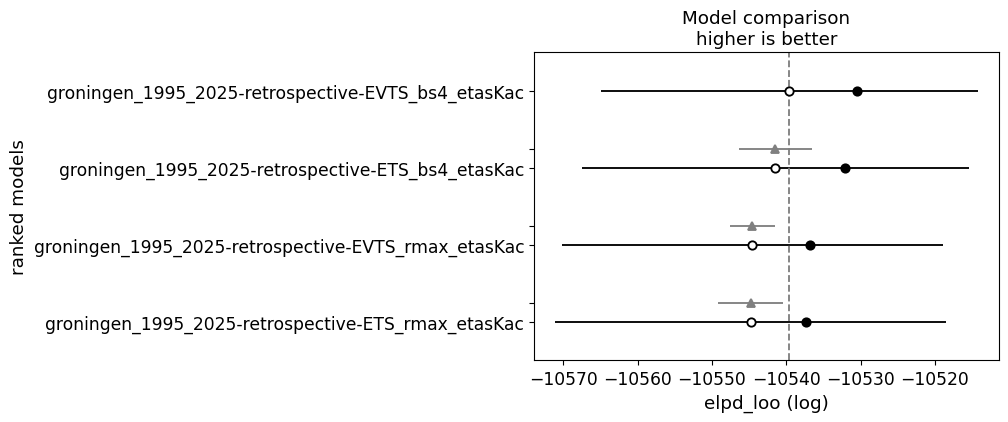

In [14]:
azc = az.compare(
    {k: v for k, v in result_collection.items() if "retrospective" in k},
    ic="loo",
    var_name="XT",
)
az.plot_compare(azc, insample_dev=True, plot_ic_diff=True)
azc